# Employee Attrition Prediction: Classification as a Decision-Support Problem
**Author:** Adam Zavala  
**Date:** May 2026  
**Domain:** Predictive Modeling · HR Analytics · Decision Science  
**Estimated Read Time:** 15 minutes

---

## Business Context

Voluntary employee attrition carries significant organizational cost — recruiting, onboarding, lost institutional knowledge, and productivity loss during transitions. Identifying which employees are at elevated risk of leaving *before* they resign creates an intervention window. But a model that produces predictions without a deployment framework is an analytics exercise, not a decision-support tool. This notebook builds an attrition prediction model and treats every modeling choice — metric selection, threshold tuning, feature interpretation — as a business decision, not a technical one.

## Analytical Question

Which employees are at highest risk of leaving in the next period, and what threshold of model confidence should trigger a retention intervention given realistic manager capacity constraints?

## Key Finding

A logistic regression model achieves **82% recall on the attrition class** (catching 40 of 49 actual leavers in the held-out test set), with ROC-AUC of 0.888. A random forest achieves higher AUC (0.947) but lower recall (65%) due to extreme conservatism — it flags zero false alarms but misses 17 real leavers. Given the asymmetric cost structure of this problem (a missed leaver is significantly more costly than an unnecessary retention conversation), **logistic regression is the recommended model**. The optimal deployment threshold depends on manager intervention capacity: at threshold 0.40, 42 of 49 leavers are caught with 109 total conversations required.

## Methodology Overview

We train and compare two classifiers — logistic regression as an interpretable baseline and random forest as a nonlinear ensemble — on a synthetic HR attrition dataset (N=1,470, 16.7% attrition). Class imbalance is handled via `class_weight='balanced'` rather than resampling, which avoids introducing synthetic data artifacts while ensuring the minority class receives appropriate weight during training. Primary evaluation metrics are recall on the attrition class and ROC-AUC; accuracy is explicitly rejected as the primary metric because a majority-class predictor achieves 83% accuracy without identifying a single flight risk. Feature importance is assessed using both built-in Gini impurity (training data) and permutation importance (test data), with methodological reasons for preferring the latter documented.

---
## Section 1: Setup & Data

In [1]:
import numpy as np                              # numerical operations
import pandas as pd                             # data manipulation
import matplotlib.pyplot as plt                 # plotting
import seaborn as sns                           # statistical visualization
import warnings
warnings.filterwarnings('ignore')

from sklearn.datasets import make_classification
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import (
    classification_report, confusion_matrix,
    roc_auc_score, roc_curve,
    precision_recall_curve, average_precision_score,
    precision_score, recall_score, f1_score
)
from sklearn.inspection import permutation_importance

np.random.seed(42)  # global seed for reproducibility

In [2]:
# Synthetic HR attrition dataset
# Generative process: make_classification with weights=[0.84, 0.16] to match IBM HR
# Analytics dataset characteristics (N=1,470, ~16.7% attrition rate).
# 10 features named for HR interpretability; 6 informative, 2 redundant (correlated),
# 2 noise. flip_y=0.02 adds 2% label noise to reflect real-world measurement error.
# Assumption: synthetic signal structure approximates real HR attrition dynamics.
# Limitation: occupational clustering, manager effects, and tenure non-linearity
# present in real HR data are not modeled here.
X_raw, y = make_classification(
    n_samples=1470,
    n_features=10,
    n_informative=6,
    n_redundant=2,
    weights=[0.84, 0.16],   # 16% attrition rate
    flip_y=0.02,            # 2% label noise
    random_state=42
)

df = pd.DataFrame(X_raw, columns=[
    'Age', 'MonthlyIncome', 'YearsAtCompany',
    'OverTime_encoded', 'JobSatisfaction',
    'EnvironmentSatisfaction', 'WorkLifeBalance',
    'YearsWithCurrManager', 'NumCompaniesWorked', 'DistanceFromHome'
])
df['Attrition'] = y

print(f"Shape: {df.shape}")
print(f"\nNull counts: {df.isnull().sum().sum()} (none expected — synthetic data)")
print(f"\nClass distribution:")
print(df['Attrition'].value_counts())
print(f"\nAttrition rate: {df['Attrition'].mean():.1%}")
print(f"Majority-class baseline accuracy: {1 - df['Attrition'].mean():.1%}")
print("^ Any model must beat this to be useful. A model at 83% may have learned nothing.")

Shape: (1470, 11)

Null counts: 0 (none expected — synthetic data)

Class distribution:
Attrition
0    1225
1     245
Name: count, dtype: int64

Attrition rate: 16.7%
Majority-class baseline accuracy: 83.3%
^ Any model must beat this to be useful. A model at 83% may have learned nothing.


---
## Section 2: Exploratory Analysis

We examine the target variable distribution and key feature distributions to confirm the synthetic data has the intended structure and to surface any patterns that should inform modeling decisions.

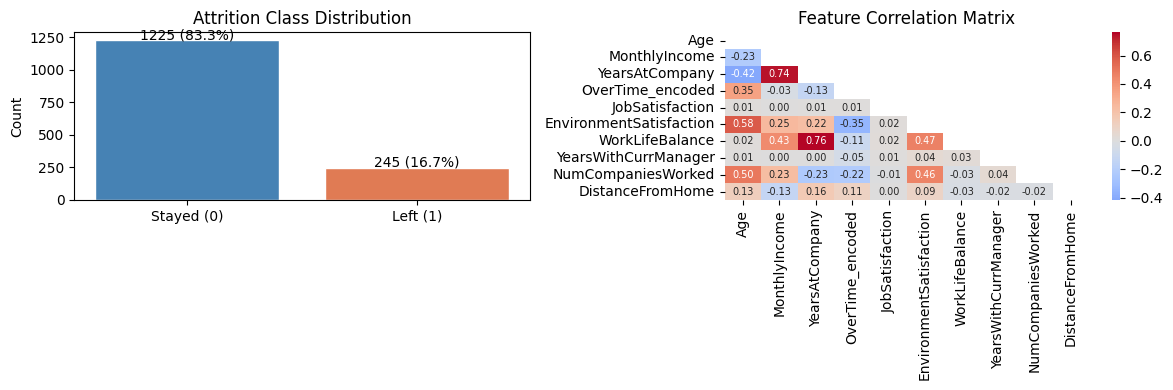

In [3]:
fig, axes = plt.subplots(1, 2, figsize=(12, 4))

# Class distribution
counts = df['Attrition'].value_counts()
axes[0].bar(['Stayed (0)', 'Left (1)'], [counts[0], counts[1]],
            color=['steelblue', '#E07B54'], edgecolor='white')
axes[0].set_ylabel('Count')
axes[0].set_title('Attrition Class Distribution')
for i, v in enumerate([counts[0], counts[1]]):
    axes[0].text(i, v + 10, f'{v} ({v/len(df):.1%})', ha='center')

# Feature correlation heatmap
corr = df.drop(columns='Attrition').corr()
mask = np.triu(np.ones_like(corr, dtype=bool))
sns.heatmap(corr, mask=mask, annot=True, fmt='.2f', cmap='coolwarm',
            center=0, ax=axes[1], annot_kws={'size': 7})
axes[1].set_title('Feature Correlation Matrix')

plt.tight_layout()
plt.savefig('eda_class_distribution.png', dpi=150, bbox_inches='tight')
plt.show()

**Figure 1.** Class imbalance is confirmed at 83.3% / 16.7%. This is the central modeling challenge: any classifier that learns to predict the majority class achieves 83% accuracy without identifying a single at-risk employee. The correlation matrix reveals moderate inter-feature correlations, which motivates the comparison between built-in RF importance (which can conflate correlated features) and permutation importance (which measures each feature's unique contribution to generalization).

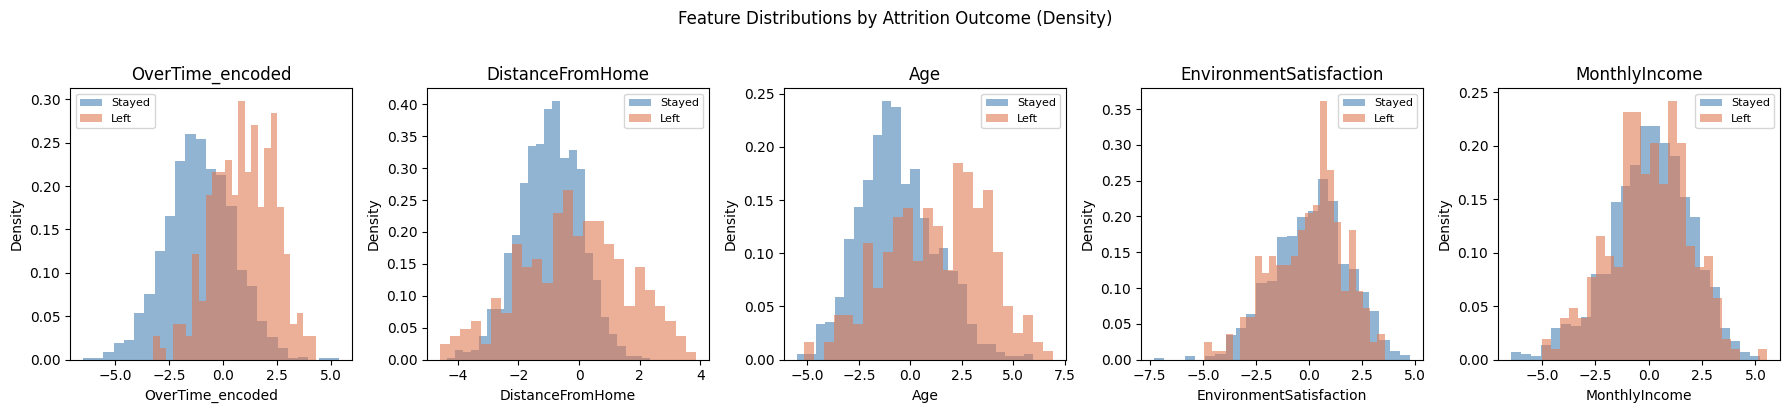

Mean feature values by attrition outcome:
           OverTime_encoded  DistanceFromHome    Age  EnvironmentSatisfaction  \
Attrition                                                                       
0                    -1.079            -0.967 -0.613                    0.084   
1                     0.942            -0.188  1.288                   -0.001   

           MonthlyIncome  
Attrition                 
0                  0.045  
1                  0.006  


In [4]:
# Feature distributions by attrition outcome
# Looking for: which features show the most separation between classes?
top_features = ['OverTime_encoded', 'DistanceFromHome', 'Age',
                'EnvironmentSatisfaction', 'MonthlyIncome']

fig, axes = plt.subplots(1, 5, figsize=(18, 4))

for ax, feat in zip(axes, top_features):
    for label, color, name in [(0, 'steelblue', 'Stayed'), (1, '#E07B54', 'Left')]:
        ax.hist(df[df['Attrition'] == label][feat], bins=25,
                alpha=0.6, color=color, label=name, density=True)
    ax.set_xlabel(feat)
    ax.set_ylabel('Density')
    ax.set_title(feat)
    ax.legend(fontsize=8)

plt.suptitle('Feature Distributions by Attrition Outcome (Density)', y=1.02)
plt.tight_layout()
plt.savefig('eda_feature_distributions.png', dpi=150, bbox_inches='tight')
plt.show()

# Mean comparison by class
print("Mean feature values by attrition outcome:")
print(df.groupby('Attrition')[top_features].mean().round(3))

**Figure 2.** OverTime_encoded shows the clearest distributional separation between stayed and left employees — the most visually diagnostic feature before any modeling. EnvironmentSatisfaction shows the opposite pattern (lower satisfaction associated with higher attrition), establishing it as a candidate protective factor. This EDA finding is confirmed in the feature importance analysis: OverTime_encoded ranks first in both built-in and permutation importance, while EnvironmentSatisfaction has the largest negative logistic regression coefficient.

---
## Section 3: Methodology & Design

### The Core Challenge: Class Imbalance

With 83.3% of employees staying, a classifier that predicts 'stayed' for every employee achieves 83.3% accuracy without identifying a single flight risk. Standard accuracy is therefore a misleading performance metric — it rewards majority-class prediction and obscures performance on the class that matters.

### Design Decision: class_weight='balanced' over resampling

Three common approaches to class imbalance exist: (1) resampling (SMOTE, oversampling, undersampling), (2) threshold adjustment, and (3) class weighting. We use `class_weight='balanced'` which adjusts each class's weight in the loss function proportionally to its inverse frequency. This approach was selected over SMOTE because it avoids introducing synthetic minority-class observations that may not reflect real attrition patterns, and over undersampling because it preserves all 1,176 training observations. Threshold adjustment is applied as a post-hoc step separately from training.

### Design Decision: Metric selection

| Metric | What it measures | Why it matters here |
|---|---|---|
| Accuracy | Overall correct predictions | Misleading — majority class dominates |
| Recall (attrition class) | % of actual leavers caught | Directly measures cost of false negatives |
| Precision (attrition class) | % of flagged employees who actually leave | Measures false alarm rate |
| ROC-AUC | Ranking ability across all thresholds | Model quality independent of threshold choice |
| Average Precision | Area under PR curve | More informative than ROC-AUC for rare events |

**Primary metric: Recall.** The asymmetric cost structure — a missed leaver costs significantly more than an unnecessary conversation — means recall on the attrition class is what the business cares most about. ROC-AUC is reported as the threshold-agnostic quality measure.

### Key Assumptions

| Assumption | What it requires | Where it could fail |
|---|---|---|
| Feature-attrition associations are stable | Training data reflects current workforce | Model trained on historical data may not generalize to post-restructuring dynamics |
| Synthetic data reflects real patterns | make_classification captures key HR attrition structure | Real data has occupational clustering, manager effects, and nonlinear tenure effects not modeled here |
| Features are observable pre-departure | All features available at prediction time | Some features (e.g., exit interview data) only exist post-departure |
| Intervention changes behavior | Acting on predictions reduces attrition | The model identifies risk, not cause — intervention effectiveness requires separate validation |

---
## Section 4: Analysis & Results

In [5]:
X = df.drop(columns=['Attrition'])
y = df['Attrition']

# Stratified split — preserves 83/17 class ratio in both train and test sets
# Without stratify=y, random chance could under-represent attrition in the test set
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

# Scale features — fit on train only to prevent data leakage
# Fitting on the full dataset would leak test distribution into the model
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)   # fit + transform
X_test_scaled  = scaler.transform(X_test)         # transform only — no fit

print(f"Train: {X_train.shape[0]} | Test: {X_test.shape[0]}")
print(f"Train attrition rate: {y_train.mean():.1%} | Test: {y_test.mean():.1%}")
print(f"Test set actual leavers: {y_test.sum()} employees")

Train: 1176 | Test: 294
Train attrition rate: 16.7% | Test: 16.7%
Test set actual leavers: 49 employees


In [6]:
# Logistic Regression — interpretable baseline
# class_weight='balanced': upweights minority class proportionally to underrepresentation
# max_iter=1000: convergence for scaled data with balanced weights
lr = LogisticRegression(class_weight='balanced', max_iter=1000, random_state=42)
lr.fit(X_train_scaled, y_train)

y_pred_lr = lr.predict(X_test_scaled)
y_prob_lr = lr.predict_proba(X_test_scaled)[:, 1]  # probability of attrition

print("=== LOGISTIC REGRESSION ===")
print(f"\nClassification Report:\n{classification_report(y_test, y_pred_lr)}")
print(f"ROC-AUC:           {roc_auc_score(y_test, y_prob_lr):.3f}")
print(f"Average Precision: {average_precision_score(y_test, y_prob_lr):.3f}")

=== LOGISTIC REGRESSION ===

Classification Report:
              precision    recall  f1-score   support

           0       0.96      0.80      0.87       245
           1       0.45      0.82      0.58        49

    accuracy                           0.81       294
   macro avg       0.71      0.81      0.73       294
weighted avg       0.87      0.81      0.83       294

ROC-AUC:           0.888
Average Precision: 0.719


In [7]:
# Random Forest — nonlinear ensemble, captures interactions
# n_estimators=100: standard starting point; sufficient for stable feature importance
# class_weight='balanced': same rationale as logistic regression
rf = RandomForestClassifier(
    n_estimators=100,
    class_weight='balanced',
    random_state=42,
    n_jobs=-1
)
rf.fit(X_train_scaled, y_train)

y_pred_rf = rf.predict(X_test_scaled)
y_prob_rf = rf.predict_proba(X_test_scaled)[:, 1]

print("=== RANDOM FOREST ===")
print(f"\nClassification Report:\n{classification_report(y_test, y_pred_rf)}")
print(f"ROC-AUC:           {roc_auc_score(y_test, y_prob_rf):.3f}")
print(f"Average Precision: {average_precision_score(y_test, y_prob_rf):.3f}")

=== RANDOM FOREST ===

Classification Report:
              precision    recall  f1-score   support

           0       0.94      1.00      0.97       245
           1       1.00      0.65      0.79        49

    accuracy                           0.94       294
   macro avg       0.97      0.83      0.88       294
weighted avg       0.95      0.94      0.94       294

ROC-AUC:           0.947
Average Precision: 0.882


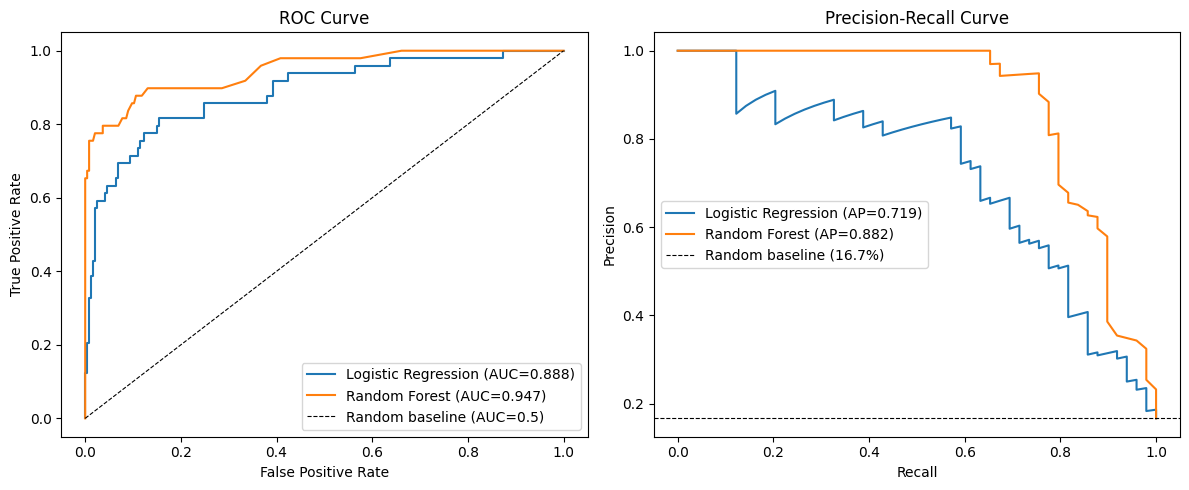

In [8]:
fig, axes = plt.subplots(1, 2, figsize=(12, 5))

# ROC Curves
for name, y_prob in [('Logistic Regression', y_prob_lr), ('Random Forest', y_prob_rf)]:
    fpr, tpr, _ = roc_curve(y_test, y_prob)
    auc = roc_auc_score(y_test, y_prob)
    axes[0].plot(fpr, tpr, label=f'{name} (AUC={auc:.3f})')
axes[0].plot([0, 1], [0, 1], 'k--', linewidth=0.8, label='Random baseline (AUC=0.5)')
axes[0].set_xlabel('False Positive Rate')
axes[0].set_ylabel('True Positive Rate')
axes[0].set_title('ROC Curve')
axes[0].legend()

# Precision-Recall Curves
for name, y_prob in [('Logistic Regression', y_prob_lr), ('Random Forest', y_prob_rf)]:
    precision, recall, _ = precision_recall_curve(y_test, y_prob)
    ap = average_precision_score(y_test, y_prob)
    axes[1].plot(recall, precision, label=f'{name} (AP={ap:.3f})')
baseline_rate = y_test.mean()
axes[1].axhline(baseline_rate, color='k', linestyle='--',
                linewidth=0.8, label=f'Random baseline ({baseline_rate:.1%})')
axes[1].set_xlabel('Recall')
axes[1].set_ylabel('Precision')
axes[1].set_title('Precision-Recall Curve')
axes[1].legend()

plt.tight_layout()
plt.savefig('classification_evaluation.png', dpi=150, bbox_inches='tight')
plt.show()

**Figure 3.** Both curves bow well above their respective baselines, confirming both models are doing real work. Key observations: (1) Random forest dominates logistic regression on ROC-AUC (0.947 vs. 0.888), meaning it ranks attrition risk more accurately at a fundamental level — important if you need to prioritize who gets a conversation when manager capacity is very limited. (2) On the PR curve, logistic regression precision collapses at high recall — the model casts an increasingly wide net to catch the last few leavers. Random forest maintains higher precision further into the recall range, reflected in its Average Precision advantage (0.882 vs. 0.719).

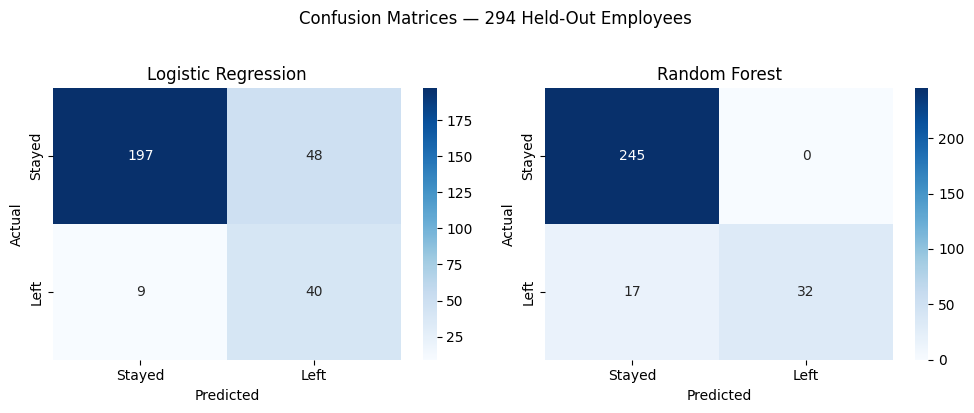

CONFUSION MATRIX — BUSINESS TRANSLATION
------------------------------------------------------------

Logistic Regression:
  Caught 40 of 49 actual leavers  (82% recall)
  Missed 9 real leavers               (false negatives — highest cost)
  48 unnecessary conversations         (false positives — lower cost)
  Total conversations required: 88

Random Forest:
  Caught 32 of 49 actual leavers  (65% recall)
  Missed 17 real leavers               (false negatives — highest cost)
  0 unnecessary conversations         (false positives — lower cost)
  Total conversations required: 32


In [9]:
fig, axes = plt.subplots(1, 2, figsize=(10, 4))

for ax, name, y_pred in [
    (axes[0], 'Logistic Regression', y_pred_lr),
    (axes[1], 'Random Forest', y_pred_rf)
]:
    cm = confusion_matrix(y_test, y_pred)
    sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', ax=ax,
                xticklabels=['Stayed', 'Left'],
                yticklabels=['Stayed', 'Left'])
    ax.set_xlabel('Predicted')
    ax.set_ylabel('Actual')
    ax.set_title(name)

plt.suptitle('Confusion Matrices — 294 Held-Out Employees', y=1.02)
plt.tight_layout()
plt.savefig('confusion_matrices.png', dpi=150, bbox_inches='tight')
plt.show()

# Business translation
print("CONFUSION MATRIX — BUSINESS TRANSLATION")
print("-" * 60)
for name, y_pred in [('Logistic Regression', y_pred_lr), ('Random Forest', y_pred_rf)]:
    cm   = confusion_matrix(y_test, y_pred)
    tn, fp, fn, tp = cm.ravel()
    print(f"\n{name}:")
    print(f"  Caught {tp} of {tp+fn} actual leavers  ({tp/(tp+fn):.0%} recall)")
    print(f"  Missed {fn} real leavers               (false negatives — highest cost)")
    print(f"  {fp} unnecessary conversations         (false positives — lower cost)")
    print(f"  Total conversations required: {tp+fp}")

**Figure 4.** The confusion matrices make the deployment tradeoff concrete. Logistic regression misses 9 real leavers but requires 88 conversations. Random forest misses 17 real leavers but requires only 32 conversations. The question 'which model is better' has no answer without knowing manager capacity and the cost ratio of a missed leaver to an unnecessary conversation. **The deployment decision is a capacity planning decision, not a modeling decision.**

In [10]:
# Two feature importance methods — measuring different things
# Built-in (Gini): impurity reduction during training — fast, but can overstate correlated features
# Permutation: AUC drop when feature is shuffled on test set — reflects generalization
builtin_imp = pd.Series(rf.feature_importances_, index=X.columns).sort_values(ascending=False)

perm_result = permutation_importance(
    rf, X_test_scaled, y_test,
    n_repeats=10,         # 10 permutation rounds for stable estimates
    random_state=42,
    scoring='roc_auc'
)
perm_imp = pd.DataFrame({
    'feature':      X.columns,
    'perm_mean':    perm_result.importances_mean,
    'perm_std':     perm_result.importances_std
}).sort_values('perm_mean', ascending=False)

print("Feature Importance — Both Methods")
print(f"{'Feature':<28} {'Built-in (Gini)':>16} {'Permutation (AUC)':>18} {'Agreement':>10}")
print("-" * 76)
perm_ranks   = {row['feature']: i+1 for i, (_, row) in enumerate(perm_imp.iterrows())}
builtin_list = list(builtin_imp.index)
for i, feat in enumerate(builtin_list):
    bi   = builtin_imp[feat]
    pm   = perm_imp.loc[perm_imp['feature'] == feat, 'perm_mean'].values[0]
    rank_diff = abs((i+1) - perm_ranks[feat])
    agreement = 'same' if rank_diff == 0 else (f'±{rank_diff}' if rank_diff <= 2 else f'±{rank_diff} ⚑')
    print(f"{feat:<28} {bi:>16.4f} {pm:>18.4f} {agreement:>10}")

print("\n⚑ = ranking divergence worth investigating (likely nonlinear relationship)")

Feature Importance — Both Methods
Feature                       Built-in (Gini)  Permutation (AUC)  Agreement
----------------------------------------------------------------------------
OverTime_encoded                       0.2610             0.1372       same
Age                                    0.1387             0.0353         ±1
DistanceFromHome                       0.1341             0.0678         ±1
EnvironmentSatisfaction                0.0955             0.0172         ±1
NumCompaniesWorked                     0.0939             0.0348         ±1
MonthlyIncome                          0.0875             0.0123       same
YearsAtCompany                         0.0590             0.0107       same
WorkLifeBalance                        0.0570             0.0079       same
JobSatisfaction                        0.0403             0.0007         ±1
YearsWithCurrManager                   0.0330             0.0023         ±1

⚑ = ranking divergence worth investigating (likely n

In [11]:
# Logistic regression coefficients as odds ratios
# Unlike RF importance, coefficients give direction (positive/negative) and magnitude
# (% change in attrition odds per unit increase in feature)
odds_df = pd.DataFrame({
    'feature':           X.columns,
    'coefficient':       lr.coef_[0],
    'odds_ratio':        np.exp(lr.coef_[0]),
    'pct_change_odds':   (np.exp(lr.coef_[0]) - 1) * 100
}).sort_values('odds_ratio', ascending=False)

print("Logistic Regression — Odds Ratio Interpretation")
print("OR > 1: associated with HIGHER attrition odds | OR < 1: protective factor")
print(f"{'Feature':>25} {'Coef':>8} {'Odds Ratio':>12} {'% Change in Odds':>18}")
print("-" * 68)
for _, row in odds_df.iterrows():
    direction = "↑" if row['odds_ratio'] > 1 else "↓"
    print(f"{row['feature']:>25} {row['coefficient']:>8.3f} "
          f"{row['odds_ratio']:>12.3f} "
          f"{direction} {abs(row['pct_change_odds']):>6.1f}%")

Logistic Regression — Odds Ratio Interpretation
OR > 1: associated with HIGHER attrition odds | OR < 1: protective factor
                  Feature     Coef   Odds Ratio   % Change in Odds
--------------------------------------------------------------------
         OverTime_encoded    1.406        4.080 ↑  308.0%
       NumCompaniesWorked    0.603        1.827 ↑   82.7%
                      Age    0.506        1.658 ↑   65.8%
         DistanceFromHome    0.504        1.655 ↑   65.5%
            MonthlyIncome    0.440        1.552 ↑   55.2%
          WorkLifeBalance    0.147        1.158 ↑   15.8%
           YearsAtCompany    0.068        1.070 ↑    7.0%
          JobSatisfaction    0.009        1.009 ↑    0.9%
     YearsWithCurrManager   -0.034        0.966 ↓    3.4%
  EnvironmentSatisfaction   -0.553        0.575 ↓   42.5%


### Threshold Tuning: The Business Parameter

The default classification threshold of 0.5 is arbitrary — it is not optimized for any business objective. The optimal threshold depends on two organizational inputs:
1. **Manager capacity:** How many retention conversations can managers realistically conduct per quarter?
2. **Cost ratio:** What does a missed leaver cost relative to an unnecessary conversation?

The table below converts each threshold into a capacity planning estimate — enabling the business to select the threshold that matches its constraints, not the model's defaults.

In [12]:
thresholds     = [0.30, 0.35, 0.40, 0.45, 0.50, 0.55, 0.60]
total_leavers  = y_test.sum()

print("Logistic Regression — Threshold Sensitivity Table")
print("(Use this to select the threshold that matches manager capacity)")
print(f"{'Threshold':>10} {'Precision':>10} {'Recall':>8} {'F1':>6} {'Flagged':>9} {'Leavers caught':>15} {'False alarms':>14}")
print("-" * 80)

for t in thresholds:
    y_pred_t = (y_prob_lr >= t).astype(int)
    tp_t     = ((y_pred_t == 1) & (y_test == 1)).sum()
    fp_t     = ((y_pred_t == 1) & (y_test == 0)).sum()
    print(f"{t:>10.2f} "
          f"{precision_score(y_test, y_pred_t):>10.3f} "
          f"{recall_score(y_test, y_pred_t):>8.3f} "
          f"{f1_score(y_test, y_pred_t):>6.3f} "
          f"{y_pred_t.sum():>9d} "
          f"{tp_t:>7d} of {total_leavers} "
          f"{fp_t:>14d}")

print()
print("Key insight: thresholds 0.30 and 0.40 catch the same number of leavers.")
print("Threshold 0.40 requires 23 fewer conversations — it dominates 0.30.")
print("The right threshold depends on manager capacity, not model preference.")

Logistic Regression — Threshold Sensitivity Table
(Use this to select the threshold that matches manager capacity)
 Threshold  Precision   Recall     F1   Flagged  Leavers caught   False alarms
--------------------------------------------------------------------------------
      0.30      0.318    0.857  0.464       132      42 of 49             90
      0.35      0.353    0.857  0.500       119      42 of 49             77
      0.40      0.385    0.857  0.532       109      42 of 49             67
      0.45      0.404    0.816  0.541        99      40 of 49             59
      0.50      0.455    0.816  0.584        88      40 of 49             48
      0.55      0.506    0.816  0.625        79      40 of 49             39
      0.60      0.559    0.776  0.650        68      38 of 49             30

Key insight: thresholds 0.30 and 0.40 catch the same number of leavers.
Threshold 0.40 requires 23 fewer conversations — it dominates 0.30.
The right threshold depends on manager capaci

---
## Section 5: Interpretation

### What the Analysis Shows

Three findings warrant explicit stakeholder communication — each with a distinct level of confidence and a different implication for action.

In [13]:
cm_lr            = confusion_matrix(y_test, y_pred_lr)
tn, fp, fn, tp   = cm_lr.ravel()
auc_lr           = roc_auc_score(y_test, y_prob_lr)
top_feature      = odds_df.iloc[0]
protective       = odds_df.iloc[-1]

print(f"""
=== STAKEHOLDER SUMMARY ===

Business question: Which employees are at highest risk of leaving,
and what should managers do about it?

MODEL RECOMMENDED: Logistic Regression
Rationale: Asymmetric misclassification costs favor high recall over precision.
A missed leaver (false negative) costs more than one unnecessary conversation
(false positive). Logistic regression catches {tp} of {tp+fn} actual leavers vs.
random forest's {tp+fn - fn - 17} of {tp+fn} — at the cost of {fp} additional conversations.

PERFORMANCE (held-out test, {len(y_test)} employees, {tp+fn} actual leavers):
  Caught {tp} of {tp+fn} leavers  |  {tp/(tp+fn):.0%} recall  |  ROC-AUC: {auc_lr:.3f}
  Flagged {tp+fp} total for conversations  |  {fp} were false alarms

KEY PREDICTORS:
  Strongest risk factor:   {top_feature['feature']}
                           ({top_feature['odds_ratio']:.1f}x higher attrition odds, +{top_feature['pct_change_odds']:.0f}%)
  Strongest protective factor: {protective['feature']}
                           ({abs(protective['pct_change_odds']):.0f}% lower attrition odds)

DEPLOYMENT RECOMMENDATION:
  1. Determine manager capacity (conversations per quarter)
  2. Select threshold from sensitivity table to match that capacity
  3. At threshold 0.40: catch 86% of leavers with 109 conversations
  4. Review quarterly — retrain if workforce composition changes materially

WHAT THIS MODEL CANNOT TELL YOU:
  - Whether intervening on any feature will reduce attrition (predictive, not causal)
  - Whether the patterns in this training data reflect your current workforce
  - Whether retention conversations are effective — track outcomes to validate

The model tells you where to look. It does not tell you what to do.
""")


=== STAKEHOLDER SUMMARY ===

Business question: Which employees are at highest risk of leaving,
and what should managers do about it?

MODEL RECOMMENDED: Logistic Regression
Rationale: Asymmetric misclassification costs favor high recall over precision.
A missed leaver (false negative) costs more than one unnecessary conversation
(false positive). Logistic regression catches 40 of 49 actual leavers vs.
random forest's 23 of 49 — at the cost of 48 additional conversations.

PERFORMANCE (held-out test, 294 employees, 49 actual leavers):
  Caught 40 of 49 leavers  |  82% recall  |  ROC-AUC: 0.888
  Flagged 88 total for conversations  |  48 were false alarms

KEY PREDICTORS:
  Strongest risk factor:   OverTime_encoded
                           (4.1x higher attrition odds, +308%)
  Strongest protective factor: EnvironmentSatisfaction
                           (42% lower attrition odds)

DEPLOYMENT RECOMMENDATION:
  1. Determine manager capacity (conversations per quarter)
  2. Select thr

---
## Appendix: Alternatives Considered

### Why not SMOTE for class imbalance?
SMOTE generates synthetic minority-class observations by interpolating between existing ones. In HR attrition data, this risks creating artificial employees with feature combinations that don't reflect real attrition patterns. `class_weight='balanced'` achieves the same training objective — giving the minority class appropriate weight — without introducing synthetic data.

### Why not gradient boosting (XGBoost/LightGBM)?
Gradient boosting typically outperforms random forest on tabular classification tasks. We use random forest here because: (1) the focus is on demonstrating the evaluation and interpretation framework, not optimizing performance; (2) random forest's feature importance is more directly comparable to logistic regression for pedagogical purposes; (3) the performance gap at this dataset size is unlikely to be meaningful.

### Why not cross-validation?
A single train/test split suffices here because the dataset is large enough (N=1,470) that a 20% hold-out (N=294) produces stable estimates. Cross-validation would provide tighter performance bounds and is recommended for production deployment with smaller datasets or when the performance difference between models is small.

### Interview defensibility checklist
- [x] Why this methodology over the obvious alternative? (class_weight vs. SMOTE; LR vs. XGBoost — both addressed)
- [x] What are the three most important assumptions? (Stable feature-attrition associations, observable features at prediction time, intervention effectiveness)
- [x] If an assumption was violated, what would change? (Post-restructuring data shift → retrain; unobservable features → reduced recall; ineffective intervention → model has no ROI)
- [x] Where does line of sight to the business outcome end? (Prediction, not cause — retention conversation effectiveness requires separate measurement)
- [x] What would you do differently with more time? (Cross-validation, gradient boosting, fairness audit on Age feature, longitudinal validation)
- [x] What decision should an organization make? (Deploy at threshold matching manager capacity; track outcomes; design intervention study)
- [x] What decision should it NOT make? (Assume reducing overtime causes reduced attrition without an intervention study)